# 국민여행조사 군집 시군구 단계구분도

## 분석 질문

`260720_국민여행조사_지역별_전체여행_집계_3개년`이 산출한
시군구별 사전 층화 군집(당일여행 C1·C2, 숙박여행 C1·C2·C3) 구성비와
가중규모는 전국 시군구에 걸쳐 어떻게 분포하는가? 그리고 연고관광
정책 대상으로 삼은 세 군집(당일여행 C1, 숙박여행 C1·C2)의 규모와
비중을 합쳤을 때 어느 시군구가 두드러지는가?

## 데이터와 결합 방식

- 군집 구성비·가중규모 표: `region_trip_feature.csv`
  (시도명·시군구명 단위, 도시는 구 단위로 나누지 않고 하나로 집계됨).
- 시군구 경계: `전국_시군구_2025_2Q.geojson`
  (`SIGUNGU_CD`·`SIGUNGU_NM`만 있고 시도명은 없음, 구 단위 유지).
- CSV는 군위군을 경상북도로 표기하지만 geojson은 군위군을 대구광역시
  코드(22XXX)로 이미 분류하고 있다. 결합 전 CSV 쪽 군위군 시도명을
  대구광역시로 고친다.
- geojson은 인천 남구를 2018년 개칭된 이름인 미추홀구로 표기하지만
  CSV는 옛 이름 남구를 그대로 쓴다. geojson 쪽 인천 미추홀구를
  남구로 고친다.
- geojson은 수원시·성남시·안양시·부천시·안산시·고양시·용인시·
  청주시·천안시·전주시·포항시·창원시를 구 단위 여러 행으로 담고
  있으므로, CSV와 같은 도시 단위가 되도록 `시군구명`의 공백 앞
  토큰(구 단위면 "OO시", 아니면 원래 이름)으로 묶어 `dissolve`한다.
- 결합 키는 시도명·시군구명 조합이다.

In [1]:
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("src 폴더가 있는 프로젝트 루트를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from src.path import RAW_DATA_DIR, create_output_directories
from src.visualization import COLORS, PALETTE, apply_plot_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_plot_style()
FIGURES_DIR, TABLES_DIR = create_output_directories(
    "260722_국민여행조사_군집_시군구_단계구분도.ipynb"
)

FEATURE_TABLE_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "260720_국민여행조사_지역별_전체여행_집계_3개년"
    / "tables"
    / "region_trip_feature.csv"
)
GEOJSON_PATH = RAW_DATA_DIR / "sigungu_map" / "전국_시군구_2025_2Q.geojson"

# 시군구 경계 SIGUNGU_CD 앞 2자리 -> 시도명 (region_trip_feature.csv 표기와 일치)
PROVINCE_BY_CODE_PREFIX = {
    "11": "서울특별시",
    "21": "부산광역시",
    "22": "대구광역시",
    "23": "인천광역시",
    "24": "광주광역시",
    "25": "대전광역시",
    "26": "울산광역시",
    "29": "세종특별자치시",
    "31": "경기도",
    "32": "강원도",
    "33": "충청북도",
    "34": "충청남도",
    "35": "전라북도",
    "36": "전라남도",
    "37": "경상북도",
    "38": "경상남도",
    "39": "제주특별자치도",
}

# 5개 사전 층화 군집의 구성비·가중규모 컬럼과 단계구분도 전용 색상.
# 색상은 PALETTE 5색을 군집 순서대로 그대로 배정해, 구성비·규모
# 단계구분도 전체에서 같은 군집은 항상 같은 색을 쓰게 한다.
CLUSTER_COLUMNS = {
    "당일여행 C1": {
        "구성비": "군집당일여행 C1_구성비",
        "가중규모": "군집당일여행 C1_가중규모",
        "color": PALETTE[0],
        "slug": "day_c1",
    },
    "당일여행 C2": {
        "구성비": "군집당일여행 C2_구성비",
        "가중규모": "군집당일여행 C2_가중규모",
        "color": PALETTE[1],
        "slug": "day_c2",
    },
    "숙박여행 C1": {
        "구성비": "군집숙박여행 C1_구성비",
        "가중규모": "군집숙박여행 C1_가중규모",
        "color": PALETTE[2],
        "slug": "stay_c1",
    },
    "숙박여행 C2": {
        "구성비": "군집숙박여행 C2_구성비",
        "가중규모": "군집숙박여행 C2_가중규모",
        "color": PALETTE[3],
        "slug": "stay_c2",
    },
    "숙박여행 C3": {
        "구성비": "군집숙박여행 C3_구성비",
        "가중규모": "군집숙박여행 C3_가중규모",
        "color": PALETTE[4],
        "slug": "stay_c3",
    },
}
# 연고관광 정책 타겟 군집: 당일여행 C1, 숙박여행 C1·C2
TARGET_CLUSTERS = ["당일여행 C1", "숙박여행 C1", "숙박여행 C2"]

print(f"군집 집계 표: {FEATURE_TABLE_PATH.relative_to(PROJECT_ROOT)}")
print(f"시군구 경계: {GEOJSON_PATH.relative_to(PROJECT_ROOT)}")

군집 집계 표: outputs\260720_국민여행조사_지역별_전체여행_집계_3개년\tables\region_trip_feature.csv
시군구 경계: data\raw\sigungu_map\전국_시군구_2025_2Q.geojson


## 1. 데이터 로드

군집 집계 표에서 결합·시각화에 쓰는 열만 남기고, 시군구 경계는
전체 속성을 그대로 불러온다.

In [2]:
feature_columns = ["시도명", "시군구명"] + [
    column
    for spec in CLUSTER_COLUMNS.values()
    for column in (spec["구성비"], spec["가중규모"])
]
feature_df = pd.read_csv(FEATURE_TABLE_PATH, usecols=feature_columns)

sigungu_gdf = gpd.read_file(GEOJSON_PATH)

print(f"군집 집계 표 행 수: {len(feature_df)}")
print(f"시군구 경계 원본 행 수(구 단위 포함): {len(sigungu_gdf)}")

군집 집계 표 행 수: 229
시군구 경계 원본 행 수(구 단위 포함): 252


## 2. 데이터 품질과 분석 단위 확인

결합 전에 두 표의 시군구 개수 차이가 온전히 도시 단위 집계(구
분할 해소) 때문인지, 군위군 시도명 표기 차이 때문인지 확인한다.

In [3]:
gunwi_row = feature_df.loc[feature_df["시군구명"] == "군위군", "시도명"]
print(f"결합 전 CSV 군위군 시도명: {gunwi_row.iloc[0]}")

gunwi_geo = sigungu_gdf.loc[
    sigungu_gdf["SIGUNGU_NM"] == "군위군", "SIGUNGU_CD"
]
print(f"시군구 경계 군위군 SIGUNGU_CD: {gunwi_geo.iloc[0]} (22XXX=대구광역시)")

incheon_namgu_in_csv = feature_df.loc[
    (feature_df["시도명"] == "인천광역시") & (feature_df["시군구명"] == "남구")
]
print(f"CSV 인천 남구 존재 여부: {not incheon_namgu_in_csv.empty}")
print(
    "시군구 경계 인천 미추홀구 SIGUNGU_NM 존재 여부: "
    f"{(sigungu_gdf['SIGUNGU_NM'] == '미추홀구').any()}"
)

# 구 단위로 나뉜 시군구명은 공백을 포함한다(예: "수원시 장안구").
split_city_count = sigungu_gdf["SIGUNGU_NM"].str.contains(" ").sum()
print(f"구 단위로 분할된 행 수: {split_city_count}")

결합 전 CSV 군위군 시도명: 경상북도
시군구 경계 군위군 SIGUNGU_CD: 22520 (22XXX=대구광역시)
CSV 인천 남구 존재 여부: True
시군구 경계 인천 미추홀구 SIGUNGU_NM 존재 여부: True
구 단위로 분할된 행 수: 35


## 3. 전처리 — 시군구 경계 도시 단위 집계와 결합 키 정리

시군구 경계에 시도명을 붙이고, 구 단위 행을 CSV와 같은 도시
단위로 `dissolve`한다. 인천 미추홀구는 CSV가 쓰는 옛 이름 남구로
고친다. CSV는 군위군 시도명을 대구광역시로 고친다.

In [4]:
sigungu_gdf["시도명"] = (
    sigungu_gdf["SIGUNGU_CD"].str[:2].map(PROVINCE_BY_CODE_PREFIX)
)
assert sigungu_gdf["시도명"].notna().all(), "매핑되지 않은 SIGUNGU_CD가 있습니다."

# "수원시 장안구" -> "수원시", "군위군" -> "군위군" (공백 없는 이름은 그대로 유지)
sigungu_gdf["시군구명"] = (
    sigungu_gdf["SIGUNGU_NM"].str.split(" ").str[0]
)
# CSV는 2018년 개칭 이전 이름(남구)을 그대로 쓴다.
is_incheon_michuhol = (
    (sigungu_gdf["시도명"] == "인천광역시")
    & (sigungu_gdf["시군구명"] == "미추홀구")
)
sigungu_gdf.loc[is_incheon_michuhol, "시군구명"] = "남구"

city_level_gdf = sigungu_gdf.dissolve(
    by=["시도명", "시군구명"], as_index=False
)[["시도명", "시군구명", "geometry"]]

feature_df = feature_df.copy()
feature_df.loc[feature_df["시군구명"] == "군위군", "시도명"] = "대구광역시"

print(f"도시 단위로 합친 시군구 경계 행 수: {len(city_level_gdf)}")
print(f"결합 후 CSV 군위군 시도명: "
      f"{feature_df.loc[feature_df['시군구명'] == '군위군', '시도명'].iloc[0]}")

도시 단위로 합친 시군구 경계 행 수: 229
결합 후 CSV 군위군 시도명: 대구광역시


In [5]:
cluster_gdf = city_level_gdf.merge(
    feature_df, on=["시도명", "시군구명"], how="outer", indicator=True
)

unmatched = cluster_gdf.loc[cluster_gdf["_merge"] != "both"]
assert unmatched.empty, f"결합되지 않은 시군구가 있습니다:\n{unmatched[['시도명', '시군구명', '_merge']]}"

cluster_gdf = cluster_gdf.drop(columns="_merge")
print(f"결합된 시군구 행 수: {len(cluster_gdf)} (기대값: {len(feature_df)})")

결합된 시군구 행 수: 229 (기대값: 229)


## 4. 분석 — 타겟 군집(당일여행 C1, 숙박여행 C1·C2) 합계 산출

정책 타겟 세 군집의 가중규모 합과 구성비 합을 각각 계산한다.

In [6]:
target_share_columns = [
    CLUSTER_COLUMNS[name]["구성비"] for name in TARGET_CLUSTERS
]
target_scale_columns = [
    CLUSTER_COLUMNS[name]["가중규모"] for name in TARGET_CLUSTERS
]

cluster_gdf["타겟군집_구성비_합"] = cluster_gdf[target_share_columns].sum(axis=1)
cluster_gdf["타겟군집_가중규모_합"] = cluster_gdf[target_scale_columns].sum(axis=1)

target_summary_table = cluster_gdf[
    ["시도명", "시군구명", "타겟군집_가중규모_합", "타겟군집_구성비_합"]
].sort_values("타겟군집_가중규모_합", ascending=False)

target_summary_table.to_csv(
    TABLES_DIR / "target_cluster_choropleth_source.csv",
    index=False,
    encoding="utf-8-sig",
)
target_summary_table.head(10)

,시도명,시군구명,타겟군집_가중규모_합,타겟군집_구성비_합
40,경기도,용인시,798755.778201,0.578279
201,제주특별자치도,서귀포시,484297.167026,0.488435
202,제주특별자치도,제주시,482462.672638,0.597228
123,부산광역시,해운대구,426564.842079,0.194068
68,경상북도,경주시,412920.091028,0.192469
177,전라남도,여수시,406646.304793,0.280323
0,강원도,강릉시,375964.950926,0.185891
54,경상남도,밀양시,352507.642194,0.171265
198,전라북도,전주시,339822.275324,0.160374
62,경상남도,통영시,332288.900145,0.326915


## 5. 시각화

구성비 단계구분도는 군집마다 다른 색상(PALETTE 5색)의 단색
그러데이션을 쓰고, 같은 군집의 규모 단계구분도에도 동일한 색을
재사용해 두 지도 세트에서 같은 군집을 바로 알아볼 수 있게 한다.
타겟 군집 합계 지도는 세 군집을 아우르므로 중립적인 `primary`
색을 쓴다.

In [7]:
def sequential_cmap(base_color: str) -> LinearSegmentedColormap:
    """배경색에서 지정한 색으로 이어지는 단색 그러데이션을 만든다.

    Args:
        base_color: 그러데이션의 끝 색상(HEX).

    Returns:
        단계구분도에 쓸 순차형 컬러맵.
    """
    return LinearSegmentedColormap.from_list(
        f"seq_{base_color}", [COLORS["background"], base_color]
    )


def plot_choropleth(
    gdf: gpd.GeoDataFrame,
    column: str,
    base_color: str,
    title: str,
    legend_label: str,
    value_format: str,
    filename: str,
) -> None:
    """시군구 단계구분도 한 장을 그려 저장한다.

    Args:
        gdf: 지오메트리와 값 열을 담은 GeoDataFrame.
        column: 색상에 매핑할 값 열 이름.
        base_color: 그러데이션의 끝 색상(HEX).
        title: 그림 제목.
        legend_label: 컬러바 레이블(예: "구성비", "가중규모").
        value_format: 컬러바 눈금에 쓸 문자열 포맷.
        filename: 저장 파일명(확장자 제외).
    """
    fig, ax = plt.subplots(figsize=(7, 8))
    gdf.plot(
        column=column,
        cmap=sequential_cmap(base_color),
        vmin=0,
        linewidth=0.3,
        edgecolor=COLORS["background"],
        legend=True,
        legend_kwds={
            "shrink": 0.6,
            "format": value_format,
            "label": legend_label,
        },
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()
    fig.savefig(FIGURES_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

### 5-1. 군집별 구성비 단계구분도

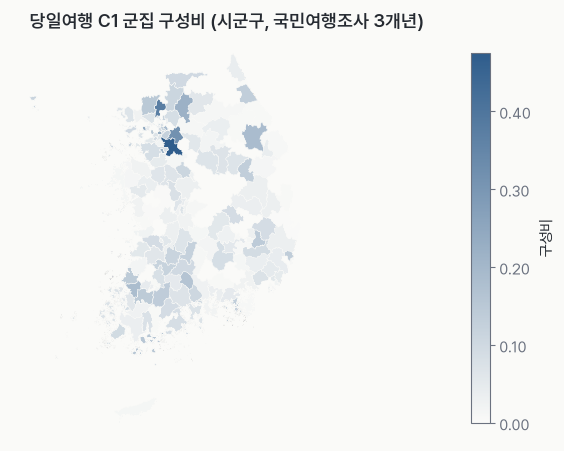

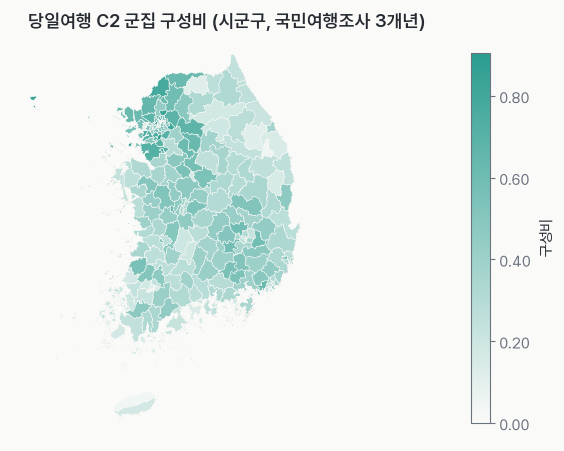

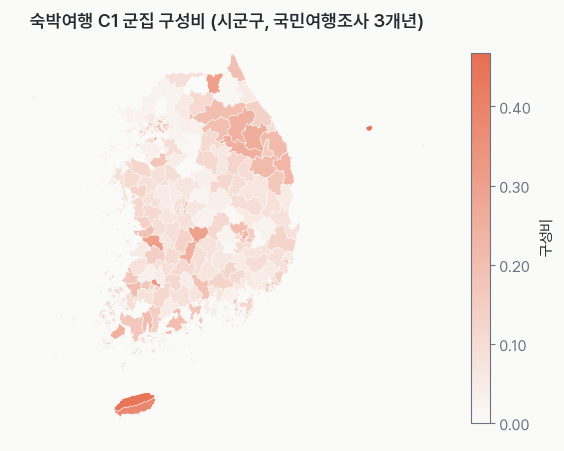

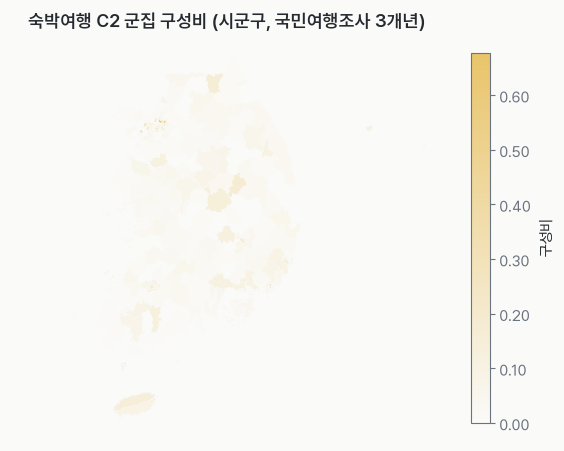

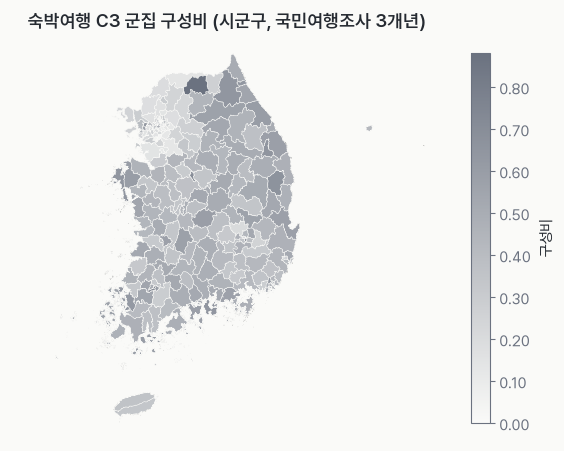

In [8]:
for cluster_name, spec in CLUSTER_COLUMNS.items():
    plot_choropleth(
        cluster_gdf,
        column=spec["구성비"],
        base_color=spec["color"],
        title=f"{cluster_name} 군집 구성비 (시군구, 국민여행조사 3개년)",
        legend_label="구성비",
        value_format="%.2f",
        filename=f"composition_share_{spec['slug']}",
    )

### 5-2. 군집별 가중규모 단계구분도

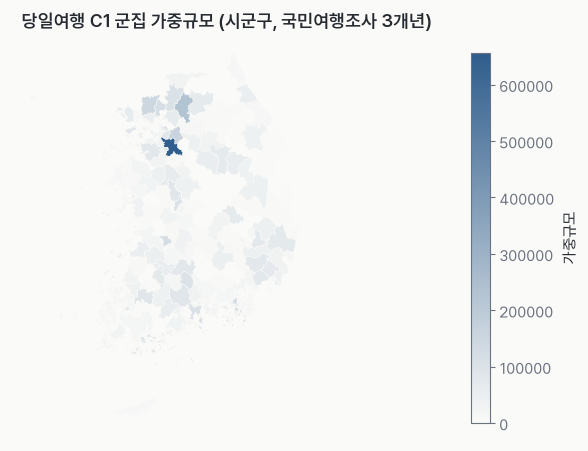

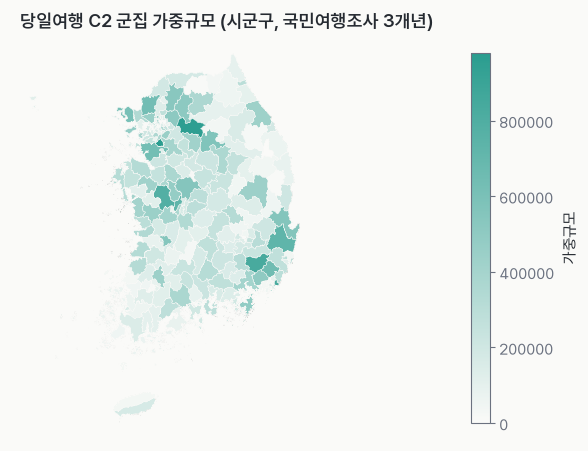

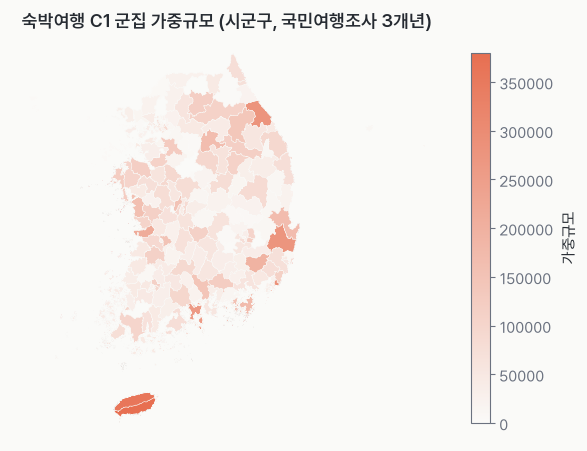

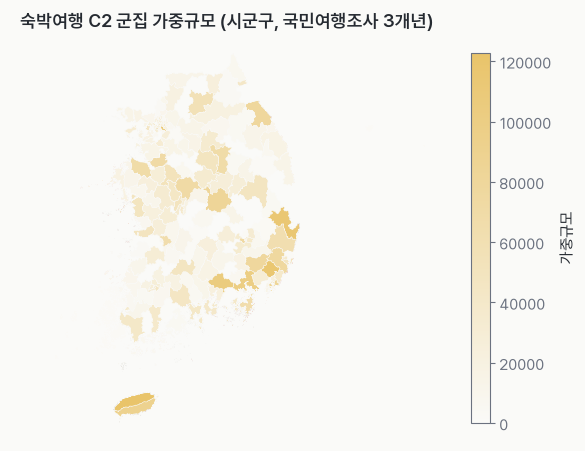

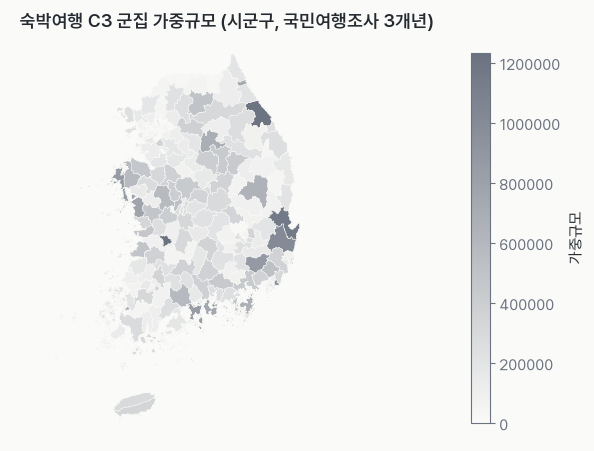

In [9]:
for cluster_name, spec in CLUSTER_COLUMNS.items():
    plot_choropleth(
        cluster_gdf,
        column=spec["가중규모"],
        base_color=spec["color"],
        title=f"{cluster_name} 군집 가중규모 (시군구, 국민여행조사 3개년)",
        legend_label="가중규모",
        value_format="%.0f",
        filename=f"cluster_size_{spec['slug']}",
    )

### 5-3. 타겟 군집(당일여행 C1, 숙박여행 C1·C2) 합계 단계구분도

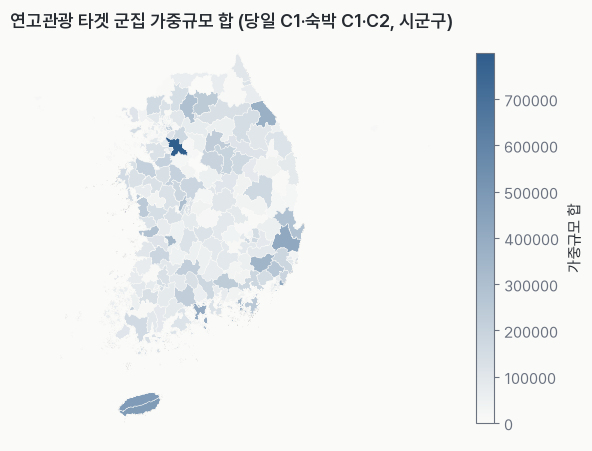

In [10]:
plot_choropleth(
    cluster_gdf,
    column="타겟군집_가중규모_합",
    base_color=COLORS["primary"],
    title="연고관광 타겟 군집 가중규모 합 (당일 C1·숙박 C1·C2, 시군구)",
    legend_label="가중규모 합",
    value_format="%.0f",
    filename="target_cluster_size_sum",
)

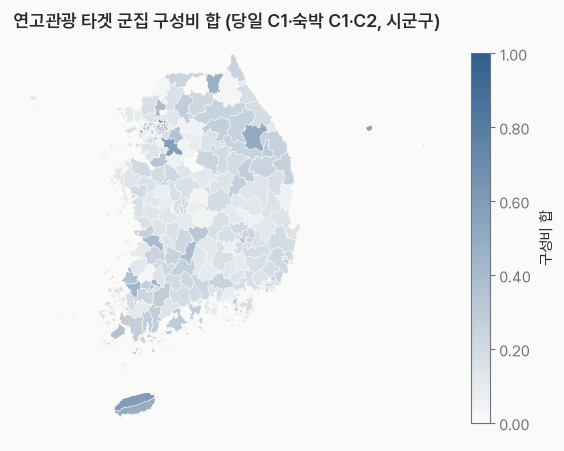

In [11]:
plot_choropleth(
    cluster_gdf,
    column="타겟군집_구성비_합",
    base_color=COLORS["primary"],
    title="연고관광 타겟 군집 구성비 합 (당일 C1·숙박 C1·C2, 시군구)",
    legend_label="구성비 합",
    value_format="%.2f",
    filename="target_cluster_share_sum",
)

## 6. 핵심 결과와 한계

- 시군구 경계(geojson, 252행)를 CSV의 도시 단위(229행)에 맞춰
  `dissolve`하고, 군위군 시도명을 대구광역시로 고쳐 시도명·
  시군구명 조합으로 결합했다. 결합 결과는 전량 일치했다(위 assert
  통과).
- 5개 군집의 구성비·가중규모 단계구분도와, 연고관광 타겟 세 군집
  (당일여행 C1, 숙박여행 C1·C2)의 가중규모 합·구성비 합 단계구분도를
  `outputs/260722_국민여행조사_군집_시군구_단계구분도/figures/`에
  저장했다.
- 구성비는 시군구 내 전체 여행 중 비중이고, 가중규모는 `WT_DOM`
  가중을 적용한 절대 규모다. 시군구 크기(면적)와 방문객 수 자체가
  병행되므로, 구성비 지도와 규모 지도를 함께 보아야 특정 군집이
  "크지만 비중은 낮은" 지역과 "작지만 비중이 높은" 지역을 구분할 수
  있다.
- 시군구 경계는 EPSG:4326(위경도)을 그대로 사용했다. 정밀한 면적
  비교가 필요하면 등적 좌표계로 재투영해야 한다.